1️⃣ What is a Kernel in SVM? (Simple idea)

👉 SVM’s goal:
To separate data using a best boundary (hyperplane).

If data is linearly separable → a straight line (2D) or plane (3D) is enough.

If data is not separable by a straight line → SVM uses a kernel trick.

🔹 Kernel = a mathematical function
that transforms data into a higher dimension where a straight line can separate it.

📌 Key idea:

“If you can’t separate data in the current space, move it to a higher space.”

2️⃣ Why do we need kernels?
Example:

Imagine this data 👇

⭕ Class A in center
❌ Class B around it

➡️ No straight line can separate them in 2D.

But if we map data into higher dimensions, suddenly:
✔️ A straight line becomes possible

This is what kernels do — without actually computing higher dimensions explicitly (this is the kernel trick).

3️⃣ Types of Kernels in SVM
🔹 1. Linear Kernel

Formula:

𝐾
(
𝑥
1
,
𝑥
2
)
=
𝑥
1
⋅
𝑥
2
K(x
1
	​

,x
2
	​

)=x
1
	​

⋅x
2
	​

Meaning:

No transformation

Data is separated using a straight line / plane

When to use:

✔ Data is linearly separable
✔ Dataset is large
✔ Features are already meaningful

Where used:

Text classification

Spam detection

Sentiment analysis

High-dimensional data

Example:
SVC(kernel='linear')


🟢 Fast & simple
🔴 Fails on complex patterns

🔹 2. Polynomial Kernel (poly)

Formula:

𝐾
(
𝑥
1
,
𝑥
2
)
=
(
𝑥
1
⋅
𝑥
2
+
𝑐
)
𝑑
K(x
1
	​

,x
2
	​

)=(x
1
	​

⋅x
2
	​

+c)
d
Meaning:

Creates curved boundaries

Degree d controls complexity

When to use:

✔ Data has polynomial relationships
✔ Moderate dataset size

Where used:

Image classification

Pattern recognition

When relationships are not straight but structured

Example:
SVC(kernel='poly', degree=3)


🟢 Can model curves
🔴 Risk of overfitting if degree is high

🔹 3. RBF Kernel (Radial Basis Function / Gaussian)

Formula:

𝐾
(
𝑥
1
,
𝑥
2
)
=
exp
⁡
(
−
𝛾
∥
𝑥
1
−
𝑥
2
∥
2
)
K(x
1
	​

,x
2
	​

)=exp(−γ∥x
1
	​

−x
2
	​

∥
2
)
Meaning:

Measures distance between points

Creates very flexible boundaries

Most powerful & commonly used kernel

When to use:

✔ Data is non-linear
✔ You don’t know data pattern
✔ Medium-sized dataset

Where used:

Medical diagnosis

Face recognition

Finance (risk prediction)

Most real-world problems

Example:
SVC(kernel='rbf', gamma='scale')


🟢 Handles complex data well
🔴 Slower, needs tuning

📌 Default kernel in SVM is RBF

4️⃣ Comparison Table
Kernel	Boundary	Use When	Pros	Cons
Linear	Straight line	Data is linear	Fast, simple	Cannot handle curves
Poly	Curved	Polynomial patterns	Flexible	Overfitting risk
RBF	Very flexible	Unknown/non-linear	Powerful	Slower, tuning needed

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"heart.csv")

In [2]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Train Test Split

In [ ]:
# Handle missing values
# df.dropna(inplace-True)

# # Encode categorical variables
# label_encoders - {}
# for col in df.select_dtypes(include=['object']).columns:
# le = LabelEncoder()
# df[col] = le.fit_transform(df[col])
# label_encoders[col] = le

In [6]:
X = df.drop("target", axis=1)
y = df["target"]

### Training the data

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)



### Standardise the data

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Linear Kernal

In [9]:
# Train SVM with Linear Kernel
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

In [20]:
# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy (Linear Kernel): {accuracy_linear:.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


Accuracy (Linear Kernel): 0.81
Confusion Matrix:
 [[72 30]
 [ 8 95]]


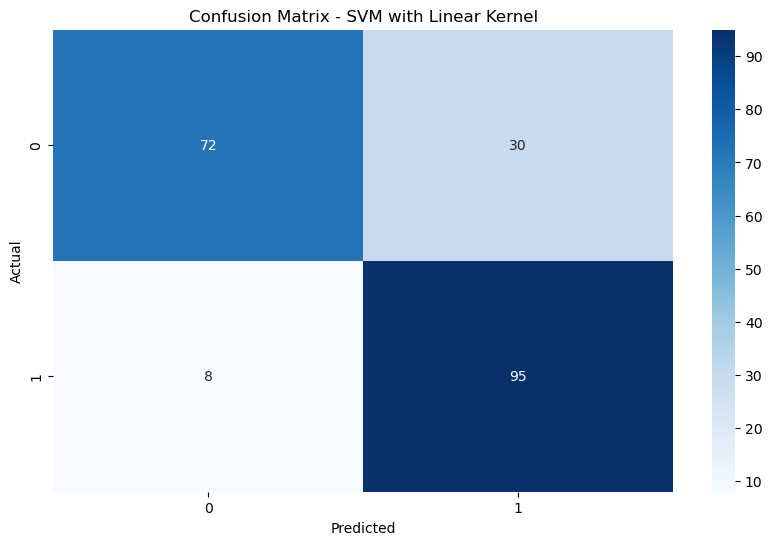

In [23]:
# Visualization of Decision Boundaries (2D Example)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM with Linear Kernel')
plt.show()

#### Polynomial Kernal

In [11]:
# Train SVM with Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3, C=1)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

In [19]:
# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy (Polynomial Kernel): {accuracy_poly:.2f}") 
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))

Accuracy (Polynomial Kernel): 0.91
Confusion Matrix:
 [[ 85  17]
 [  2 101]]


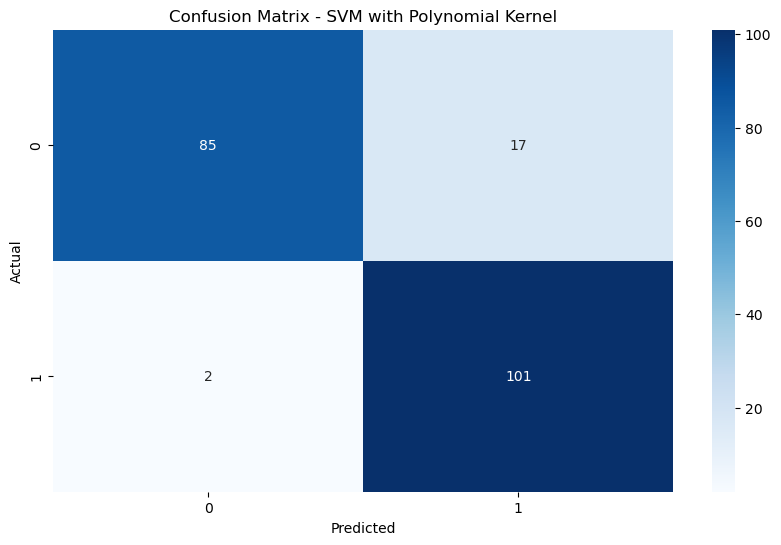

In [24]:
# Visualization of Decision Boundaries 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_poly), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM with Polynomial Kernel')
plt.show()

#### RBF Kernal

In [16]:
# Train SVM with RBF Kernel
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

In [18]:
# Accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy (RBF Kernel): {accuracy_rbf:.2f}") 
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Accuracy (RBF Kernel): 0.89
Confusion Matrix:
 [[85 17]
 [ 6 97]]


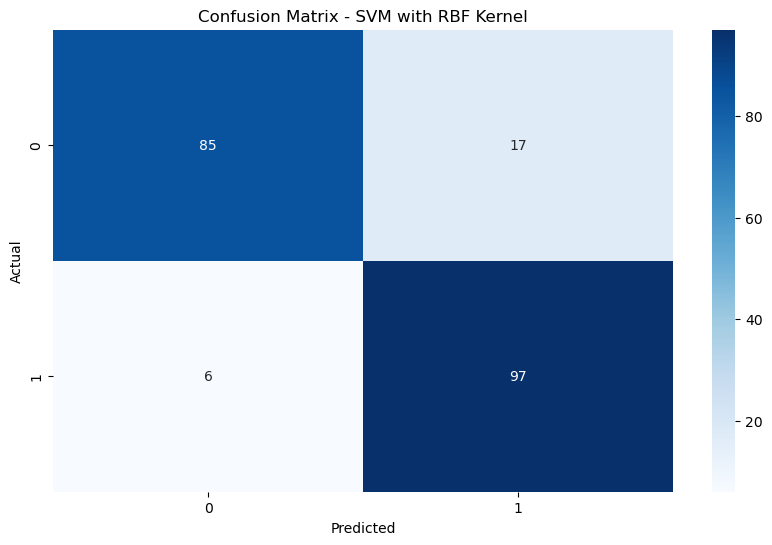

In [25]:
# Visualization of Decision Boundaries (2D Example)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM with RBF Kernel')
plt.show()